# AI Cargo Monitoring -- EDA & Data Quality Report

Exploratory analysis of `single_table.csv`: 7 408 telemetry windows across
140 shipments, 254 legs, 6 products, 7 transit phases.

**Target**: `target_spoilage_risk_6h` (binary, ~17 % positive).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, pathlib

sns.set_theme(style="whitegrid", palette="muted")
DATA = pathlib.Path("../data")

df = pd.read_csv(DATA / "single_table.csv", parse_dates=["window_start", "window_end"])
profiles = json.loads((DATA / "product_profiles.json").read_text())

print(f"Rows: {len(df):,}  Columns: {df.shape[1]}")
df.head()

Rows: 7,408  Columns: 19


,window_id,leg_id,shipment_id,container_id,product_id,window_start,window_end,avg_temp_c,max_temp_c,min_temp_c,temp_slope_c_per_hr,humidity_avg_pct,shock_count,door_open_count,minutes_outside_range,current_delay_min,battery_avg_pct,transit_phase,target_spoilage_risk_6h
0,W00001,L0001,S001,C330,P02,2026-04-01 16:47:00,2026-04-01 17:12:00,5.032,5.103,4.982,-0.2335,53.24,0,0,0,0.0,91.94,loading_zone,0
1,W00002,L0001,S001,C330,P02,2026-04-01 17:17:00,2026-04-01 17:42:00,5.080,5.188,4.962,0.1584,56.15,0,0,0,0.5,91.83,loading_zone,0
2,W00003,L0001,S001,C330,P02,2026-04-01 17:47:00,2026-04-01 18:12:00,5.090,5.153,5.051,-0.0885,56.14,0,0,0,0.7,91.72,loading_zone,0
3,W00004,L0001,S001,C330,P02,2026-04-01 18:17:00,2026-04-01 18:42:00,4.971,5.076,4.907,-0.3885,55.29,0,0,0,1.1,91.61,loading_zone,0
4,W00005,L0001,S001,C330,P02,2026-04-01 18:47:00,2026-04-01 19:12:00,4.801,5.017,4.591,-0.8702,57.33,0,0,0,1.2,91.51,loading_zone,0


## 1. Schema & Missing Values

In [2]:
print("=== Data types ===")
print(df.dtypes)
print("\n=== Null counts ===")
print(df.isnull().sum())
print("\n=== Unique counts ===")
for c in ["shipment_id", "leg_id", "container_id", "product_id", "transit_phase"]:
    print(f"  {c}: {df[c].nunique()}")

=== Data types ===
window_id                          object
leg_id                             object
shipment_id                        object
container_id                       object
product_id                         object
window_start               datetime64[ns]
window_end                 datetime64[ns]
avg_temp_c                        float64
max_temp_c                        float64
min_temp_c                        float64
temp_slope_c_per_hr               float64
humidity_avg_pct                  float64
shock_count                         int64
door_open_count                     int64
minutes_outside_range               int64
current_delay_min                 float64
battery_avg_pct                   float64
transit_phase                      object
target_spoilage_risk_6h             int64
dtype: object

=== Null counts ===
window_id                  0
leg_id                     0
shipment_id                0
container_id               0
product_id                 0
win

## 2. Container-Product Mapping (one container = one product)

In [3]:
cp = df.groupby("container_id")["product_id"].nunique()
assert (cp == 1).all(), "Assumption violated: some containers carry multiple products!"
print("Confirmed: every container carries exactly one product type.")
print(df[["container_id", "product_id"]].drop_duplicates().sort_values("container_id").to_string(index=False))

Confirmed: every container carries exactly one product type.
container_id product_id
        C100        P01
        C205        P03
        C330        P02
        C410        P04
        C515        P06
        C620        P05


## 3. Target Distribution

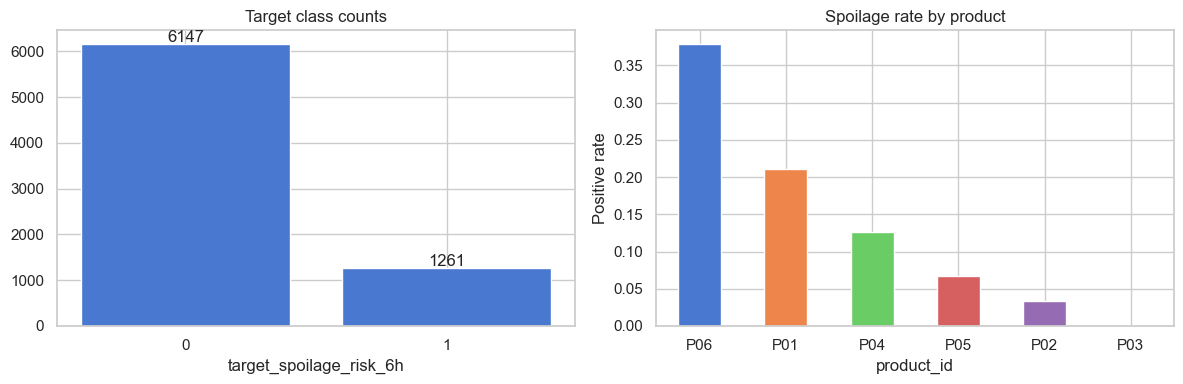

            spoilage_rate
product_id               
P06              0.378028
P01              0.211250
P04              0.126047
P05              0.066897
P02              0.033126
P03              0.000000


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vc = df["target_spoilage_risk_6h"].value_counts()
axes[0].bar(vc.index.astype(str), vc.values)
axes[0].set_title("Target class counts")
axes[0].set_xlabel("target_spoilage_risk_6h")
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 50, str(v), ha="center")

rate = df.groupby("product_id")["target_spoilage_risk_6h"].mean().sort_values(ascending=False)
rate.plot.bar(ax=axes[1], color=sns.color_palette("muted", len(rate)))
axes[1].set_title("Spoilage rate by product")
axes[1].set_ylabel("Positive rate")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()
print(rate.to_frame("spoilage_rate").to_string())

## 4. Temperature Profiles by Product

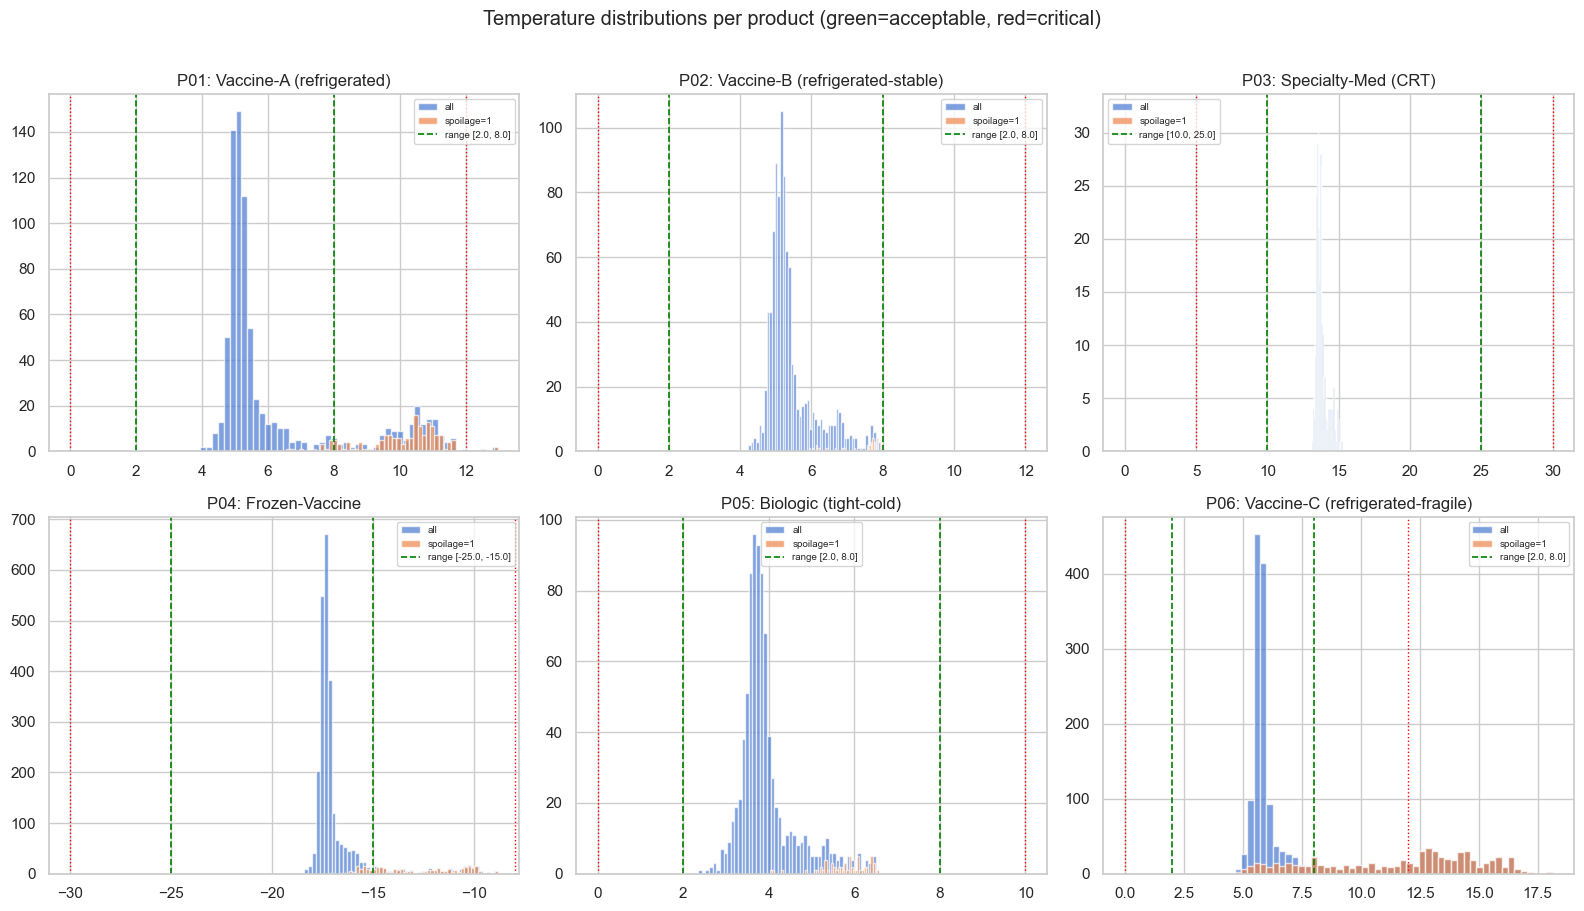

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=False)
for ax, (pid, grp) in zip(axes.flat, df.groupby("product_id")):
    prof = profiles[pid]
    ax.hist(grp["avg_temp_c"], bins=50, alpha=0.7, label="all")
    ax.hist(grp.loc[grp["target_spoilage_risk_6h"] == 1, "avg_temp_c"], bins=50, alpha=0.7, label="spoilage=1")
    ax.axvline(prof["temp_low"], color="green", ls="--", lw=1.2, label=f'range [{prof["temp_low"]}, {prof["temp_high"]}]')
    ax.axvline(prof["temp_high"], color="green", ls="--", lw=1.2)
    ax.axvline(prof["temp_critical_low"], color="red", ls=":", lw=1)
    ax.axvline(prof["temp_critical_high"], color="red", ls=":", lw=1)
    ax.set_title(f"{pid}: {prof['name']}")
    ax.legend(fontsize=7)
plt.suptitle("Temperature distributions per product (green=acceptable, red=critical)", y=1.01)
plt.tight_layout()
plt.show()

## 5. Feature Distributions (numeric)

In [6]:
num_cols = ["avg_temp_c", "max_temp_c", "min_temp_c", "temp_slope_c_per_hr",
            "humidity_avg_pct", "shock_count", "door_open_count",
            "minutes_outside_range", "current_delay_min", "battery_avg_pct"]

df[num_cols].describe().round(3)

,avg_temp_c,max_temp_c,min_temp_c,temp_slope_c_per_hr,humidity_avg_pct,shock_count,door_open_count,minutes_outside_range,current_delay_min,battery_avg_pct
count,7408.000,7408.000,7408.000,7408.000,7408.000,7408.000,7408.000,7408.00,7408.000,7408.000
mean,-1.468,-1.371,-1.565,0.043,56.034,0.003,0.011,3.91,119.008,80.206
std,11.675,11.680,11.669,0.501,3.353,0.064,0.221,10.03,177.731,9.073
min,-18.413,-18.377,-18.467,-7.222,50.390,0.000,0.000,0.00,0.000,65.670
25%,-17.090,-16.992,-17.177,-0.222,54.330,0.000,0.000,0.00,3.700,71.350
50%,4.926,5.018,4.832,0.047,55.250,0.000,0.000,0.00,11.100,80.035
75%,5.820,5.909,5.731,0.332,56.260,0.000,0.000,0.00,201.700,87.090
max,18.131,18.297,18.047,1.907,76.730,3.000,6.000,30.00,616.700,98.960


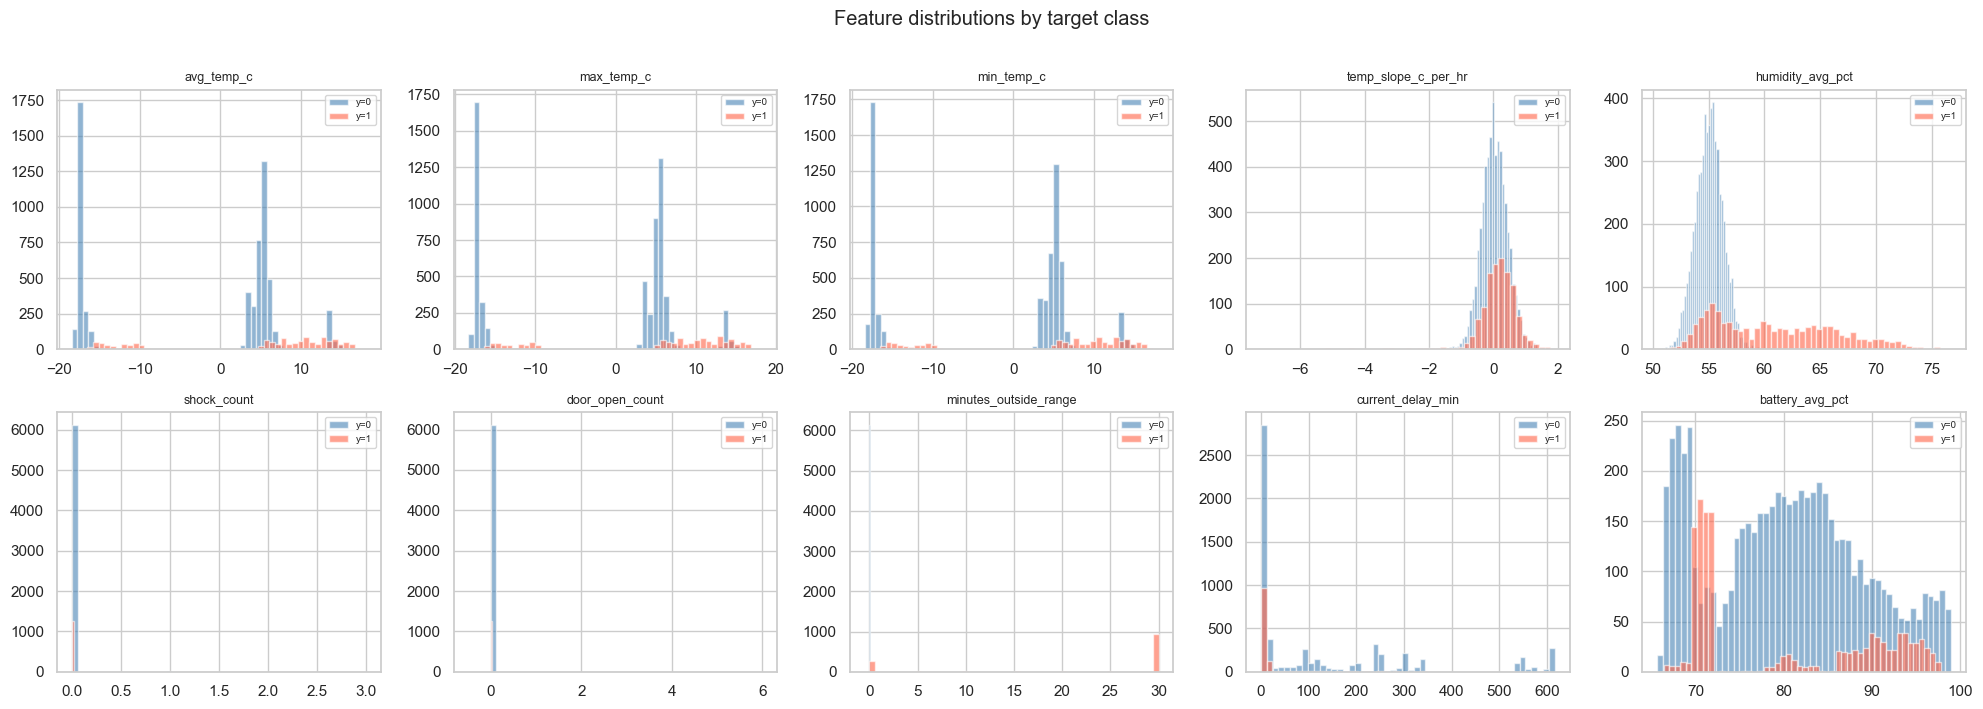

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, col in zip(axes.flat, num_cols):
    for label, color in [(0, "steelblue"), (1, "tomato")]:
        subset = df.loc[df["target_spoilage_risk_6h"] == label, col]
        ax.hist(subset, bins=50, alpha=0.6, color=color, label=f"y={label}")
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)
plt.suptitle("Feature distributions by target class", y=1.01)
plt.tight_layout()
plt.show()

## 6. Sparse Features: shock_count & door_open_count

In [8]:
for col in ["shock_count", "door_open_count"]:
    vc = df[col].value_counts().sort_index()
    pct_zero = (df[col] == 0).mean() * 100
    print(f"\n{col} -- {pct_zero:.1f}% zeros")
    print(vc.to_string())


shock_count -- 99.7% zeros
shock_count
0    7386
1      21
3       1

door_open_count -- 99.7% zeros
door_open_count
0    7386
1       3
2       1
3       4
4       7
5       4
6       3


## 7. minutes_outside_range vs Target (leakage check)

In [9]:
neg_nonzero = ((df["target_spoilage_risk_6h"] == 0) & (df["minutes_outside_range"] > 0)).sum()
pos_zero = ((df["target_spoilage_risk_6h"] == 1) & (df["minutes_outside_range"] == 0)).sum()
pos_total = (df["target_spoilage_risk_6h"] == 1).sum()

print(f"Negatives with minutes_outside_range > 0: {neg_nonzero}")
print(f"Positives with minutes_outside_range = 0:  {pos_zero} / {pos_total}  ({pos_zero/pos_total:.1%})")
print()
print("Finding: minutes_outside_range > 0 perfectly implies target=1,")
print("but many positives have it at 0 (risk is building but hasn't breached yet).")
print("Use in deterministic layer; exclude raw value from ML features.")

Negatives with minutes_outside_range > 0: 0
Positives with minutes_outside_range = 0:  265 / 1261  (21.0%)

Finding: minutes_outside_range > 0 perfectly implies target=1,
but many positives have it at 0 (risk is building but hasn't breached yet).
Use in deterministic layer; exclude raw value from ML features.


## 8. Spoilage Rate by Transit Phase

                     count  spoilage_rate  avg_delay  avg_temp_slope
transit_phase                                                       
air_handoff           2587          0.201    138.278           0.023
customs_clearance     1733          0.180    182.907           0.047
loading_zone          2319          0.174     78.593           0.020
sea_transit             49          0.163     23.880           0.270
last_mile              306          0.059     36.134           0.179
cold_store_transfer    329          0.000     27.152           0.137
road_transit            85          0.000     41.067           0.194


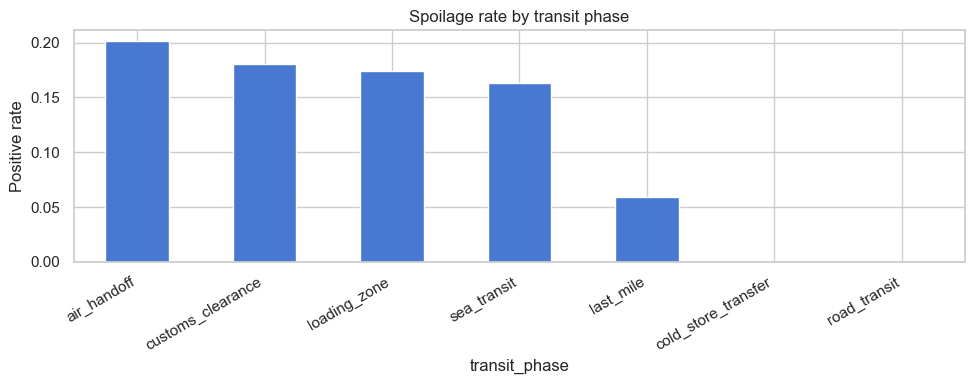

In [10]:
phase_stats = df.groupby("transit_phase").agg(
    count=("window_id", "size"),
    spoilage_rate=("target_spoilage_risk_6h", "mean"),
    avg_delay=("current_delay_min", "mean"),
    avg_temp_slope=("temp_slope_c_per_hr", "mean"),
).sort_values("spoilage_rate", ascending=False)

print(phase_stats.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
phase_stats["spoilage_rate"].plot.bar(ax=ax)
ax.set_title("Spoilage rate by transit phase")
ax.set_ylabel("Positive rate")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 9. Correlation Matrix (numeric features)

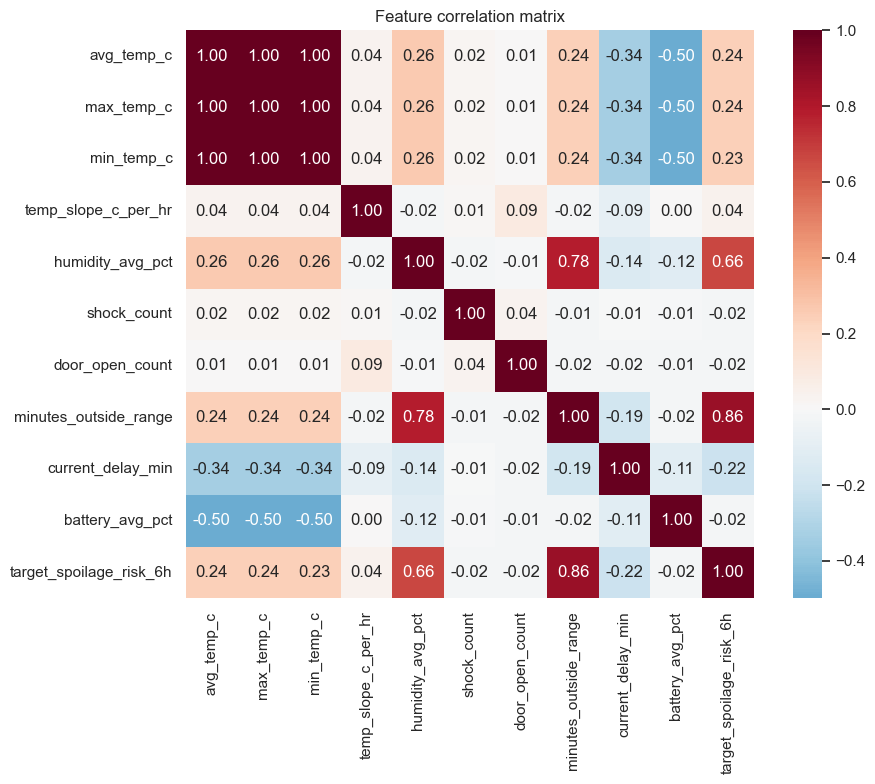

In [11]:
corr_cols = num_cols + ["target_spoilage_risk_6h"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, square=True)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

## 10. Data Quality Summary

| Finding | Impact | Recommendation |
|---------|--------|-----------------|
| `shock_count` 99.7% zero | Unusable for ML | Add realistic shocks at handoff phases in data gen |
| `door_open_count` 99.8% zero | Unusable for ML | Add door events at loading/cold-store in data gen |
| `minutes_outside_range` > 0 → always target=1 | Leaky for ML | Use in deterministic engine only; lag-transform for ML |
| P03 has 0 positive labels | Under-modeled | Add CRT excursion scenarios (>25C) in data gen |
| P06 has 37.8% spoilage rate | Dominates positives | Ensure stratified splitting by product |
| 17% class imbalance | ML bias toward negative | Use scale_pos_weight ~4.9 in XGBoost |
| No nulls detected | Clean | No action needed |
| Container-product is 1:1 | Validates assumption | Use (shipment, container, window) as composite key |